<a href="https://colab.research.google.com/github/germfsip/Agentes-Inteligentes-2026/blob/main/Unir_AI_Sesion2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 2 — Colab Práctico: Keras vs PyTorch

**Asignatura:** Sistemas Cognitivos Artificiales · UNIR México

**Profesor:** Prof. Gerardo Mtz

**Objetivo:** Clasificar dígitos escritos a mano (MNIST) con dos frameworks:
1. **Ejemplo 1:** TensorFlow / Keras (API de alto nivel)
2. **Ejemplo 2:** PyTorch (control explícito del training loop)
3. **Bonus:** Learning Rate Finder (método del codo)

---

## 0. Setup e instalación

In [13]:
# Verificar GPU disponible
import subprocess
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                       capture_output=True, text=True)
print('GPU:', result.stdout.strip() if result.returncode == 0 else 'No GPU detectada (usará CPU)')

# Instalar LR finder
!pip install -q keras-lr-finder torch-lr-finder

GPU: Tesla T4, 15360 MiB


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo de gráficas
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

TEAL = '#0098CD'
ORANGE = '#F5A623'
print('✓ Setup completo')

✓ Setup completo


---
## Ejemplo 1: Clasificador MNIST con TensorFlow / Keras

**Flujo:** Cargar datos → Definir modelo → Compilar → Entrenar → Evaluar

En Keras, este flujo completo se realiza en **~10 líneas de código**.

### 1.1 Cargar y explorar el dataset MNIST

In [15]:
import tensorflow as tf
from tensorflow import keras

print(f'TensorFlow version: {tf.__version__}')

# Cargar MNIST (viene integrado en Keras)
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f'\nDatos de entrenamiento: {X_train.shape} → {X_train.shape[0]:,} imágenes de {X_train.shape[1]}×{X_train.shape[2]} px')
print(f'Datos de test:          {X_test.shape} → {X_test.shape[0]:,} imágenes')
print(f'Clases: {np.unique(y_train)} (dígitos 0-9)')
print(f'Rango de píxeles: [{X_train.min()}, {X_train.max()}]')

TensorFlow version: 2.20.0

Datos de entrenamiento: (60000, 28, 28) → 60,000 imágenes de 28×28 px
Datos de test:          (10000, 28, 28) → 10,000 imágenes
Clases: [0 1 2 3 4 5 6 7 8 9] (dígitos 0-9)
Rango de píxeles: [0, 255]


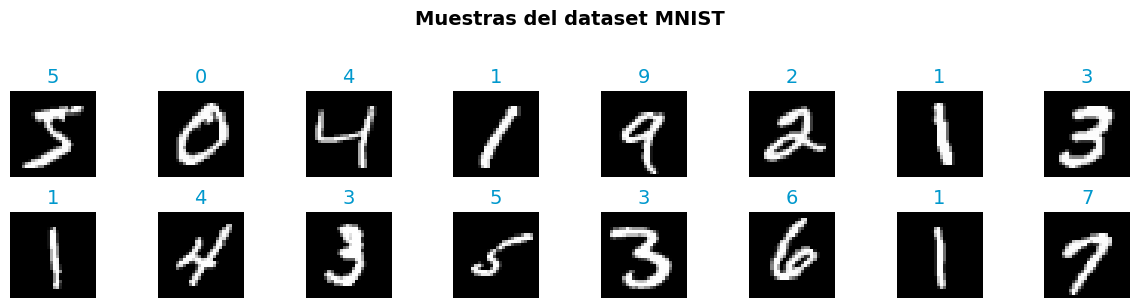

In [16]:
# Visualizar algunas muestras
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'{y_train[i]}', fontsize=14, color=TEAL)
    ax.axis('off')
plt.suptitle('Muestras del dataset MNIST', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.2 Preprocesamiento

In [17]:
# Normalizar: dividir entre 255 para que los valores queden en [0, 1]
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32') / 255.0

print(f'Rango después de normalizar: [{X_train_norm.min():.1f}, {X_train_norm.max():.1f}]')
print(f'\n¿Por qué normalizar?')
print('  → Los valores pequeños y uniformes facilitan que los gradientes fluyan')
print('  → Las funciones de activación trabajan mejor en este rango')
print('  → La inicialización de pesos está calibrada para inputs ~N(0,1)')

Rango después de normalizar: [0.0, 1.0]

¿Por qué normalizar?
  → Los valores pequeños y uniformes facilitan que los gradientes fluyan
  → Las funciones de activación trabajan mejor en este rango
  → La inicialización de pesos está calibrada para inputs ~N(0,1)


### 1.3 Definir el modelo con Keras Sequential

In [18]:
# Definir la arquitectura del modelo
model_keras = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),       # 28×28 → 784
    keras.layers.Dense(128, activation='relu'),        # Capa oculta con ReLU
    keras.layers.Dropout(0.2),                         # Regularización: apaga 20% de neuronas
    keras.layers.Dense(10, activation='softmax')       # 10 clases → probabilidades
])

# Resumen de la arquitectura
model_keras.summary()

print(f'\n📊 Total de parámetros: {model_keras.count_params():,}')
print(f'   → Flatten: 0 parámetros (solo reordena)')
print(f'   → Dense(128): 784×128 + 128 bias = {784*128 + 128:,}')
print(f'   → Dropout: 0 parámetros (solo apaga neuronas)')
print(f'   → Dense(10): 128×10 + 10 bias = {128*10 + 10:,}')

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


📊 Total de parámetros: 101,770
   → Flatten: 0 parámetros (solo reordena)
   → Dense(128): 784×128 + 128 bias = 100,480
   → Dropout: 0 parámetros (solo apaga neuronas)
   → Dense(10): 128×10 + 10 bias = 1,290


### 1.4 Compilar y entrenar

In [19]:
# Compilar: definir optimizador, función de coste y métricas
model_keras.compile(
    optimizer='adam',                              # Adam: lr=0.001 por defecto
    loss='sparse_categorical_crossentropy',        # Para etiquetas enteras (0-9)
    metrics=['accuracy']
)

# Entrenar
print('Entrenando...')
history_keras = model_keras.fit(
    X_train_norm, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,      # 20% de los datos para validación
    verbose=1
)

Entrenando...
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9051 - loss: 0.3246 - val_accuracy: 0.9494 - val_loss: 0.1798
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9527 - loss: 0.1606 - val_accuracy: 0.9659 - val_loss: 0.1171
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9648 - loss: 0.1182 - val_accuracy: 0.9719 - val_loss: 0.0968
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9706 - loss: 0.0948 - val_accuracy: 0.9743 - val_loss: 0.0882
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9753 - loss: 0.0805 - val_accuracy: 0.9752 - val_loss: 0.0828
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9786 - loss: 0.0697 - val_accuracy: 0.9755 - val_loss: 0.0821
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9795 - loss: 0.0629 - val_accuracy: 0.9755 - val_loss: 0.0843
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9830 - 

### 1.5 Evaluar y visualizar resultados

In [20]:
# Evaluar en el test set
test_loss, test_acc = model_keras.evaluate(X_test_norm, y_test, verbose=0)
print(f'\n🎯 Resultados en TEST SET:')
print(f'   Loss:     {test_loss:.4f}')
print(f'   Accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')


🎯 Resultados en TEST SET:
   Loss:     0.0703
   Accuracy: 0.9801 (98.0%)


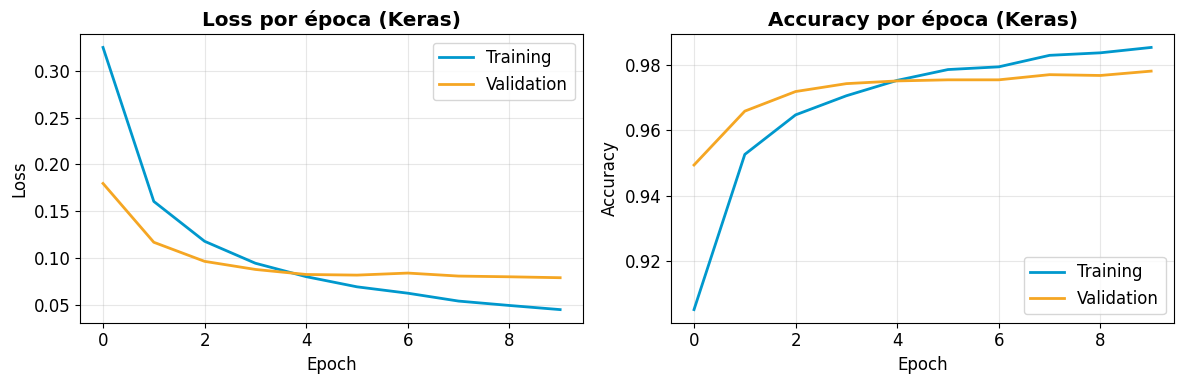


Gap entre training y validation loss: 0.0340
✅ Gap pequeño → el modelo generaliza bien (no hay overfitting significativo)


In [21]:
# Curvas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(history_keras.history['loss'], color=TEAL, lw=2, label='Training')
ax1.plot(history_keras.history['val_loss'], color=ORANGE, lw=2, label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss por época (Keras)', fontweight='bold')
ax1.legend()

# Accuracy
ax2.plot(history_keras.history['accuracy'], color=TEAL, lw=2, label='Training')
ax2.plot(history_keras.history['val_accuracy'], color=ORANGE, lw=2, label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy por época (Keras)', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

# Interpretación
gap = history_keras.history['val_loss'][-1] - history_keras.history['loss'][-1]
print(f'\nGap entre training y validation loss: {gap:.4f}')
if gap < 0.1:
    print('✅ Gap pequeño → el modelo generaliza bien (no hay overfitting significativo)')
else:
    print('⚠️  Gap considerable → posible overfitting, considerar más regularización')

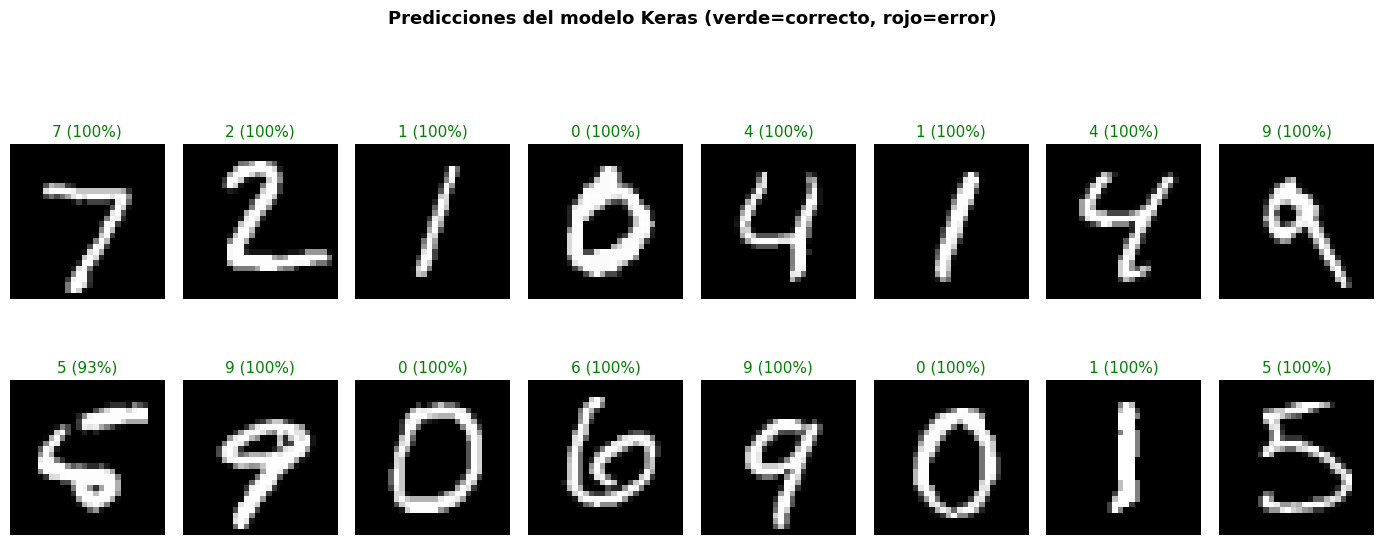

In [22]:
# Predicciones visuales
predictions = model_keras.predict(X_test_norm[:16], verbose=0)

fig, axes = plt.subplots(2, 8, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i], cmap='gray')
    pred = np.argmax(predictions[i])
    conf = predictions[i][pred] * 100
    color = 'green' if pred == y_test[i] else 'red'
    ax.set_title(f'{pred} ({conf:.0f}%)', fontsize=11, color=color)
    ax.axis('off')

plt.suptitle('Predicciones del modelo Keras (verde=correcto, rojo=error)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
##Ejemplo 2: Clasificador MNIST con PyTorch

**Mismo problema, diferente filosofía.**

En PyTorch definimos explícitamente:
- La arquitectura como una clase
- El loop de entrenamiento paso a paso
- Forward pass → Loss → Backward → Step

### 2.1 Cargar datos con PyTorch

In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {device}')

# Transformaciones: convertir a tensor + normalizar
transform = transforms.Compose([
    transforms.ToTensor(),          # Convierte a tensor [0, 1]
    # No normalizamos más allá para mantener la comparación justa con Keras
])

# Cargar datasets
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoaders: manejo automático de batches y shuffle
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

print(f'\nTraining: {len(train_dataset):,} imágenes en {len(train_loader):,} batches')
print(f'Test:     {len(test_dataset):,} imágenes en {len(test_loader):,} batches')

PyTorch version: 2.11.0+cu128
Usando: cuda

Training: 60,000 imágenes en 1,875 batches
Test:     10,000 imágenes en 313 batches


### 2.2 Definir la arquitectura (misma que Keras)

In [24]:
class MNISTClassifier(nn.Module):
    """Red neuronal idéntica a la de Keras:
       Flatten → Linear(128) + ReLU → Dropout(0.2) → Linear(10)
    """
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()                    # 28×28 → 784
        self.fc1     = nn.Linear(784, 128)             # Capa oculta
        self.relu    = nn.ReLU()                       # Activación
        self.dropout = nn.Dropout(0.2)                 # Regularización
        self.fc2     = nn.Linear(128, 10)              # Capa de salida

    def forward(self, x):
        """Define cómo fluyen los datos por la red (forward pass)."""
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)    # Sin softmax: CrossEntropyLoss lo incluye
        return x

# Instanciar y mover a GPU si disponible
model_pytorch = MNISTClassifier().to(device)
print(model_pytorch)

total_params = sum(p.numel() for p in model_pytorch.parameters())
print(f'\n📊 Total de parámetros: {total_params:,}')

MNISTClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

📊 Total de parámetros: 101,770


### 2.3 Definir loss y optimizador

In [25]:
# CrossEntropyLoss incluye softmax internamente
criterion = nn.CrossEntropyLoss()

# Adam con lr=0.001 (mismo que Keras)
optimizer = optim.Adam(model_pytorch.parameters(), lr=0.001)

print('Loss function: CrossEntropyLoss (incluye log_softmax + NLLLoss)')
print('Optimizer:     Adam (lr=0.001)')

Loss function: CrossEntropyLoss (incluye log_softmax + NLLLoss)
Optimizer:     Adam (lr=0.001)


### 2.4 Training loop (el corazón de PyTorch)

In [26]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Entrena un epoch completo."""
    model.train()  # Modo entrenamiento (activa Dropout)
    total_loss = 0
    correct = 0
    total = 0

    for batch_X, batch_y in loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # 1. Limpiar gradientes previos
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(batch_X)

        # 3. Calcular loss
        loss = criterion(outputs, batch_y)

        # 4. Backward pass (backpropagation automática)
        loss.backward()

        # 5. Actualizar pesos (SGD/Adam step)
        optimizer.step()

        # Estadísticas
        total_loss += loss.item() * batch_X.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(batch_y).sum().item()
        total += batch_y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evalúa el modelo sin actualizar pesos."""
    model.eval()  # Modo evaluación (desactiva Dropout)
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():  # No calcular gradientes
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            total_loss += loss.item() * batch_X.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(batch_y).sum().item()
            total += batch_y.size(0)

    return total_loss / total, correct / total

print('✓ Funciones de entrenamiento y evaluación definidas')
print('\n📝 Observen el loop: zero_grad → forward → loss → backward → step')
print('   Esto es EXACTAMENTE backpropagation + SGD que vimos en clase')

✓ Funciones de entrenamiento y evaluación definidas

📝 Observen el loop: zero_grad → forward → loss → backward → step
   Esto es EXACTAMENTE backpropagation + SGD que vimos en clase


In [27]:
# Entrenar
EPOCHS = 10
history_pytorch = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# Separar validación (simular el validation_split de Keras)
val_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
# Usar los últimos 12,000 como validación
train_sub = torch.utils.data.Subset(train_dataset, range(0, 48000))
val_sub   = torch.utils.data.Subset(val_dataset,   range(48000, 60000))
train_sub_loader = DataLoader(train_sub, batch_size=32, shuffle=True)
val_sub_loader   = DataLoader(val_sub,   batch_size=32, shuffle=False)

print(f'Entrenando {EPOCHS} epochs...')
print(f'{"Epoch":>5} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>10} | {"Val Acc":>9}')
print('-' * 55)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model_pytorch, train_sub_loader, criterion, optimizer, device)
    val_loss, val_acc     = evaluate(model_pytorch, val_sub_loader, criterion, device)

    history_pytorch['train_loss'].append(train_loss)
    history_pytorch['train_acc'].append(train_acc)
    history_pytorch['val_loss'].append(val_loss)
    history_pytorch['val_acc'].append(val_acc)

    print(f'{epoch+1:>5} | {train_loss:>10.4f} | {train_acc:>8.4f} | {val_loss:>10.4f} | {val_acc:>8.4f}')

Entrenando 10 epochs...
Epoch | Train Loss | Train Acc |   Val Loss |   Val Acc
-------------------------------------------------------
    1 |     0.3560 |   0.8987 |     0.1752 |   0.9497
    2 |     0.1707 |   0.9504 |     0.1228 |   0.9647
    3 |     0.1258 |   0.9626 |     0.1097 |   0.9673
    4 |     0.1036 |   0.9688 |     0.0980 |   0.9719
    5 |     0.0875 |   0.9730 |     0.0926 |   0.9725
    6 |     0.0764 |   0.9763 |     0.0863 |   0.9748
    7 |     0.0656 |   0.9790 |     0.0832 |   0.9761
    8 |     0.0597 |   0.9808 |     0.0833 |   0.9766
    9 |     0.0529 |   0.9822 |     0.0802 |   0.9772
   10 |     0.0493 |   0.9842 |     0.0822 |   0.9772


### 2.5 Evaluar y visualizar resultados

In [28]:
# Evaluación final en test set
test_loss_pt, test_acc_pt = evaluate(model_pytorch, test_loader, criterion, device)
print(f'\n🎯 Resultados en TEST SET (PyTorch):')
print(f'   Loss:     {test_loss_pt:.4f}')
print(f'   Accuracy: {test_acc_pt:.4f} ({test_acc_pt*100:.1f}%)')


🎯 Resultados en TEST SET (PyTorch):
   Loss:     0.0762
   Accuracy: 0.9782 (97.8%)


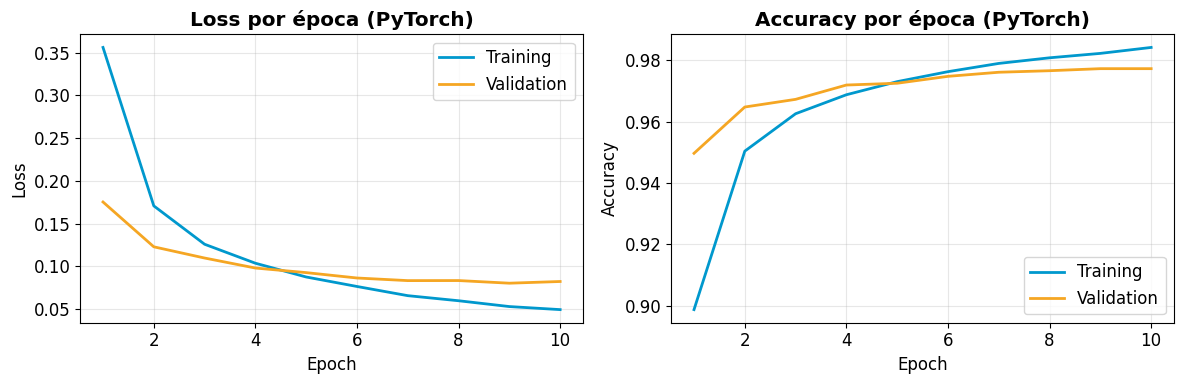

In [29]:
# Curvas de entrenamiento PyTorch
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, EPOCHS + 1)

ax1.plot(epochs_range, history_pytorch['train_loss'], color=TEAL, lw=2, label='Training')
ax1.plot(epochs_range, history_pytorch['val_loss'], color=ORANGE, lw=2, label='Validation')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss por época (PyTorch)', fontweight='bold')
ax1.legend()

ax2.plot(epochs_range, history_pytorch['train_acc'], color=TEAL, lw=2, label='Training')
ax2.plot(epochs_range, history_pytorch['val_acc'], color=ORANGE, lw=2, label='Validation')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy por época (PyTorch)', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

---
## 🔴 Comparación: Keras vs PyTorch

In [30]:
print('=' * 60)
print(f'{"":>25} {"Keras":>12} {"PyTorch":>12}')
print('=' * 60)
print(f'{"Test Accuracy":>25} {test_acc*100:>11.1f}% {test_acc_pt*100:>11.1f}%')
print(f'{"Test Loss":>25} {test_loss:>12.4f} {test_loss_pt:>12.4f}')
print(f'{"Líneas de código (aprox)":>25} {"~10":>12} {"~35":>12}')
print(f'{"Control del loop":>25} {"Automático":>12} {"Manual":>12}')
print(f'{"Debugging":>25} {"Limitado":>12} {"Nativo":>12}')
print(f'{"Uso típico":>25} {"Producción":>12} {"Investigación":>12}')
print('=' * 60)
print(f'\n✅ Ambos logran ~97-98% accuracy con la misma arquitectura.')
print(f'   La diferencia está en la FILOSOFÍA, no en el RENDIMIENTO.')

                                 Keras      PyTorch
            Test Accuracy        98.0%        97.8%
                Test Loss       0.0703       0.0762
 Líneas de código (aprox)          ~10          ~35
         Control del loop   Automático       Manual
                Debugging     Limitado       Nativo
               Uso típico   Producción Investigación

✅ Ambos logran ~97-98% accuracy con la misma arquitectura.
   La diferencia está en la FILOSOFÍA, no en el RENDIMIENTO.


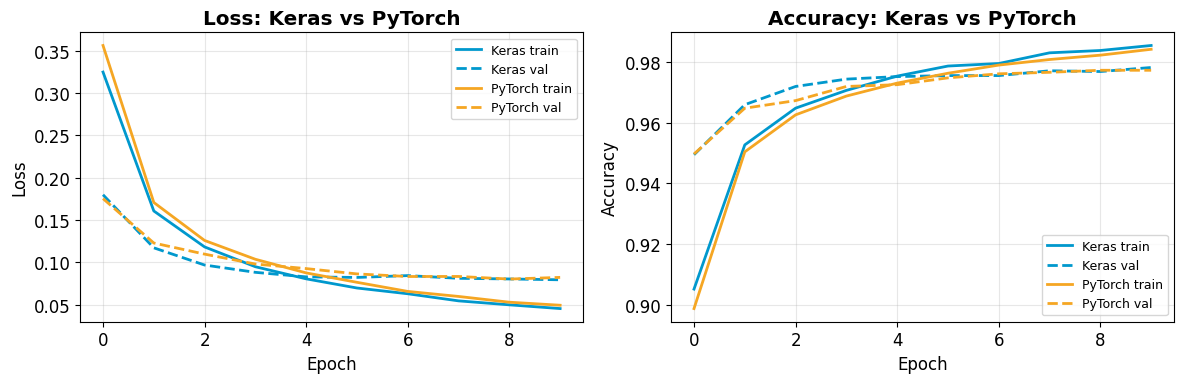

In [31]:
# Comparación visual de curvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss comparison
ax1.plot(history_keras.history['loss'], color=TEAL, lw=2, label='Keras train', ls='-')
ax1.plot(history_keras.history['val_loss'], color=TEAL, lw=2, label='Keras val', ls='--')
ax1.plot(history_pytorch['train_loss'], color=ORANGE, lw=2, label='PyTorch train', ls='-')
ax1.plot(history_pytorch['val_loss'], color=ORANGE, lw=2, label='PyTorch val', ls='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss: Keras vs PyTorch', fontweight='bold')
ax1.legend(fontsize=9)

# Accuracy comparison
ax2.plot(history_keras.history['accuracy'], color=TEAL, lw=2, label='Keras train', ls='-')
ax2.plot(history_keras.history['val_accuracy'], color=TEAL, lw=2, label='Keras val', ls='--')
ax2.plot(history_pytorch['train_acc'], color=ORANGE, lw=2, label='PyTorch train', ls='-')
ax2.plot(history_pytorch['val_acc'], color=ORANGE, lw=2, label='PyTorch val', ls='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy: Keras vs PyTorch', fontweight='bold')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 🟡 Bonus: Learning Rate Finder (Método del Codo)

El **Learning Rate Range Test** de Leslie Smith (2015):
1. Entrena brevemente incrementando la lr exponencialmente
2. Registra la loss en cada paso
3. Busca el **codo**: punto antes de que la loss empiece a subir

/usr/local/lib/python3.13/dist-packages/torch_lr_finder/lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/200 [00:00<?, ?it/s]

Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 3.74E-03


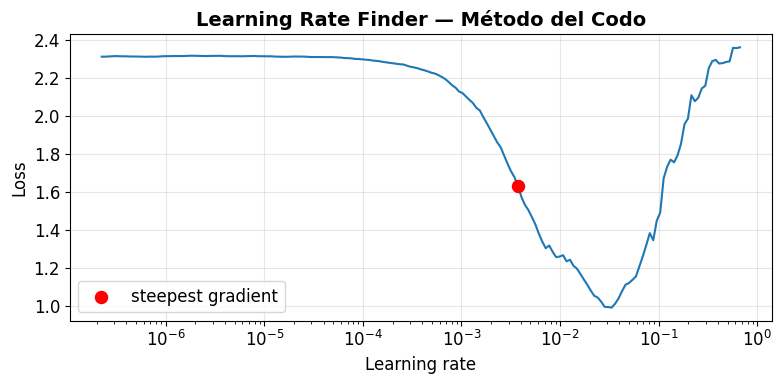


📌 Interpretación:
   → Buscar el punto donde la loss tiene la mayor pendiente de bajada
   → Ese es el "codo" — la learning rate óptima
   → Para Adam, típicamente ~1e-3 (confirma el default de 0.001)


In [32]:
# LR Finder con PyTorch
from torch_lr_finder import LRFinder

# Crear modelo fresco (no entrenado)
model_lr = MNISTClassifier().to(device)
optimizer_lr = optim.Adam(model_lr.parameters(), lr=1e-7)
criterion_lr = nn.CrossEntropyLoss()

# Ejecutar el range test
lr_finder = LRFinder(model_lr, optimizer_lr, criterion_lr, device=device)
lr_finder.range_test(train_sub_loader, end_lr=1, num_iter=200)

# Graficar
fig, ax = plt.subplots(figsize=(8, 4))
lr_finder.plot(ax=ax)
ax.set_title('Learning Rate Finder — Método del Codo', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

lr_finder.reset()  # Restaurar el modelo

print('\n📌 Interpretación:')
print('   → Buscar el punto donde la loss tiene la mayor pendiente de bajada')
print('   → Ese es el "codo" — la learning rate óptima')
print('   → Para Adam, típicamente ~1e-3 (confirma el default de 0.001)')

---
## 📝 Resumen y conclusiones

| Aspecto | TF/Keras | PyTorch |
|---|---|---|
| Líneas de código | ~10 | ~35 |
| Curva de aprendizaje | Baja | Media |
| Control del loop | Automático | Manual |
| Debugging | Limitado | Nativo Python |
| Uso principal | Producción | Investigación |
| Accuracy MNIST | ~97-98% | ~97-98% |

**Recomendación:** Aprendan ambos. Keras para ser productivos hoy, PyTorch para cuando necesiten ir más allá de lo estándar.

### 🏋️ Ejercicios para practicar:
1. Cambiar la arquitectura: agregar una segunda capa Dense(64) con ReLU
2. Modificar el Dropout a 0.5 y observar el efecto en las curvas
3. Cambiar el optimizador a SGD (lr=0.01, momentum=0.9) y comparar
4. Probar con Fashion-MNIST en vez de MNIST (cambiar una sola línea)
5. Usar el LR Finder con SGD en vez de Adam